# Clustering

# 1. Overview
+ Clustering is an unsupervised learning technique that groups similar data points together based on their features.
+ **Goal**: To partition a dataset into **distinct groups (clusters)** such that data points within the same cluster are more similar to each other than to those in other clusters.
---
+ Types of clustering Methods:
  + **Partitional Clustering(划分聚类)**: 
    + Divides data into non-overlapping subsets (e.g., K-means).
    + Each data point belongs to exactly one cluster.
  + **Hierarchical Clustering(层次聚类)**: 
    + Builds a tree of clusters (e.g., Agglomerative, Divisive).
---
+ Types of Clusters:
  + **Well-separated Clusters(分离良好的聚类)**: 
    + Any pair of data points from different clusters are farther apart than any pair of data points from the same cluster.
  + **Center-based Clustering(基于中心的聚类)**: 
    + Clusters are defined by a central point (e.g., K-means).
    + The data points in a cluster are closer to the cluster center than to any other cluster center.
  + **Contigouous Clustering(连续聚类)**: 
    + Clusters are defined by connected regions in the feature space (e.g., DBSCAN).
    + The data points in a cluster are connected to each other by paths of neighboring points.
  + **Density-based Clustering(基于密度的聚类)**: 
    + Clusters are defined as areas of higher density than the remainder of the data set (e.g., DBSCAN).
    + Clusters are formed by connecting areas of high density, and noise points are those that do not belong to any cluster.
  + **Objective Function Clustering(基于目标函数的聚类)**: 
    + Clusters are defined by optimizing a specific objective function (e.g., K-means minimizes the within-cluster sum of squares).
    + The goal is to find a partition of the data that **minimizes (or maximizes)** the objective function.
    + There are two types of objective functions:
      + **Local Objective Function(局部目标函数)**: 
        + Depends only on the data points in the same cluster (e.g., K-means).
      + **Global Objective Function(全局目标函数)**: 
        + Depends on the data points in all clusters (e.g., Spectral Clustering).

# 2. Algorithms of Clustering

## 2.1 K-means Clustering
+ Partitional clustering
+ Center-based clustering
+ Objective function clustering (local objective function)

+ **Core idea**:
  + Each cluster is associated with a centroid (the mean of the data points in the cluster).
  + Each data point is assigned to the cluster with the nearest centroid.

### 2.1.1 Algorithm:
+ **Input**: 
  + A set of data points $X = \{x_1, x_2, ..., x_n\}$ where $x_i \in \mathbb{R}^d$
  + The number of clusters $K$.
+ **Output**: 
  + A partition of the data points into $K$ clusters $C = \{C_1, C_2, ..., C_K\}$.
+ **Steps**:
  1. **Initialization**: 
    + Randomly select $K$ data points as the initial centroids $\mu_1, \mu_2, ..., \mu_K$.
  2. **Assignment Step**: 
    + For each data point $x_i$, assign it to the cluster with the nearest centroid:
    $$C_j = \{x_i : \|x_i - \mu_j\|^2 \leq \|x_i - \mu_k\|^2 \text{ for all } k = 1, 2, ..., K\}$$
  3. **Update Step**: 
    + For each cluster $C_j$, update the centroid $\mu_j$ to be the mean of the data points in the cluster:
    $$\mu_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i$$
  4. **Repeat**: 
    + Repeat steps 2 and 3 until convergence (i.e., when the centroids won't change anymore).
    + Which also means that the centroids are the geometric median of the data points in the cluster.
+ **Time complexity**: $O(nKId)$ where:
  + $n$ is the number of data points,
  + $K$ is the number of clusters,
  + $I$ is the number of iterations until convergence,
  + $d$ is the dimensionality of the data.

+ Many details:
  + Because the first step is random, the output of K-means isn't deterministic. 
  + The results also depend on the number of clusters $K$.
  + In practice, K-means offen converges in a few iterations($5~10$). So we also set some stop condictions like:
    + Maximum number of iterations.
    + Minimum change in centroids(The change of centroids is less than a threshold).
    + Minimum number of changes of cluster.(Only a few cluster assignments change).

### 2.1.2 Use K-means in practice:
+ Objective Function:
  + Most common performance measure of k-means is **Sum of Squared Error (SSE)**. For each data point, the error is defined as the distance to the nearest cluster center. So the objective function is:
  $$
  SSE = \sum_{i=1}^K \sum_{x \in C_i} \|x - \mu_i\|^2
  $$
  + Obviously, the goal of K-means is to minimize the SSE. The cluster with the smallest SSE is the best clustering result.
+ Choosing $K$:
  + When $K$ increases, the SSE will decrease. Consider the extreme case when $K=n$, each data point is its own cluster, then the SSE will be $0$. So we need to balance the number of clusters and the SSE. One common method is to use the **Elbow Method** to find the optimal number of clusters.
  + Elbow Method:
    + Core idea:
      + When $K$ increases, the SSE will decrease. But the rate of decrease will slow down after a certain point. The point where the rate of decrease slows down is called the "elbow point". The optimal number of clusters is at the elbow point.
      + That $K$ is considered to be the optimal number of clusters because it provides a good balance between the SSE and the number of clusters.
+ Initialization of centroids:
  + The random initialization of centroids can lead to different results. Here are some common solutions to improve the initialization:
    + **Multiple runs**: 
      + Run K-means multiple times with different random initializations and choose the best result (the one with the lowest SSE).
    + **Sample & Use Hierarchical Clustering**: 
      + Sampling a subset of the original data.
      + Apply hierarchical clustering to the sample to find initial centroids.
    + **K-means++**:
      + Randomly choose $M>K$ data points as candidates for centroids.
      + Find the most scattered $K$ points among the candidates to be the initial centroids.
    + **Post-processing**:
      + After running K-means, check the results.
      + If some clusters are empty, reinitialize the centroids of those clusters and run K-means again.
      + If some clusters have huge SSE, partition those clusters.
    + **Bisecting K-means**:
      + Start with all data points in one cluster.
      + Iteratively split the cluster with the highest SSE into two clusters using K-means until $K$ clusters are formed.
+ Handling empty clusters:
  + Choose the point with the largest contribution to the SSE.
    + Find the point that take the largest contribution to the SSE (i.e., the point that is farthest from its assigned cluster center).
    + Reassign that point to the empty cluster and update the cluster centers.
  + Select at the cluster with the largest SSE.
    + Find the cluster with the largest SSE, select the data point in it that is farthest from the cluster center.
    + Reassign that point to the empty cluster and update the cluster centers.
+ Update of centroids:
  + Standard K-means:
    + Each round/iteration, update all the cluster centers after assigning all data points to clusters.
  + Online K-means:
    + Update the cluster center immediately after assigning each data point to a cluster.
    + Pros:
      + Converges faster in practice.
      + Never produces empty clusters.
    + Cons:
      + More sensitive to the order of data points.
      + Bigger computational cost per iteration.
+ Pre-processing:
  + Standardization:
    + Standardization can be done by subtracting the mean and dividing by the standard deviation for each feature.
  + Remove outliers:
    + Outliers can be detected using methods like Z-score, IQR, or visual inspection.
+ Post-processing:
  + Remove the tiny clusters (clusters with very few data points) if they are not meaningful.
  + Merge the small clusters if they are close to each other and have similar characteristics.
  + Split the large clusters if they have high SSE and are not well-separated.

### 2.1.3 Limitations of K-means:
+ Sensitivity to the size of clusters:
  + K-means tends to create clusters of similar size, which can be problematic if the true clusters in the data have different sizes.
+ Can't deal with non-convex clusters:
  + K-means assumes that clusters are convex and isotropic (i.e., they have the same variance in all directions). It may fail to capture the structure of non-convex clusters.
+ Sensitivity to outliers:
  + K-means is sensitive to outliers because it uses the mean to update the cluster centers. Outliers can significantly affect the position of the cluster centers and lead to poor clustering results.

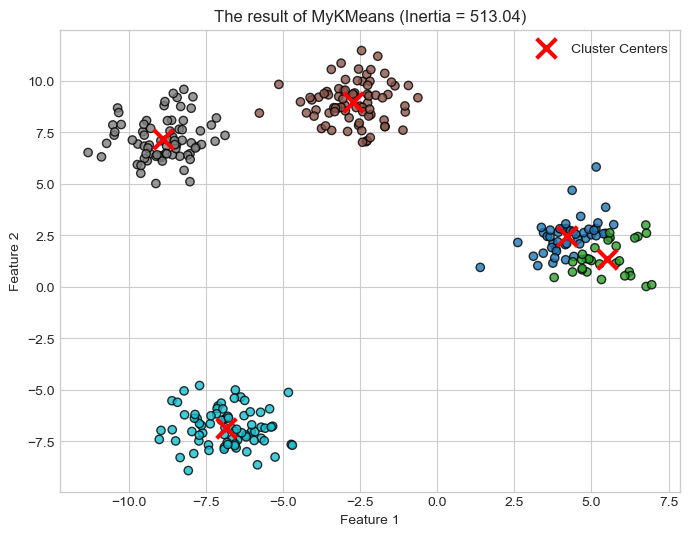

In [3]:
from sklearn.utils import check_array
from sklearn.base import BaseEstimator, ClusterMixin
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


class MyKMeans(BaseEstimator, ClusterMixin):
    def __init__(self, n_clusters=8, max_iter=300, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y=None):
        X = check_array(X, dtype=[np.float64, np.float32])
        n_samples, n_features = X.shape
        if self.n_clusters > n_samples:
            raise ValueError("n_clusters cannot be larger than n_samples.")
        
        rng = np.random.default_rng(self.random_state)
        self.cluster_centers_ = X[rng.choice(n_samples, self.n_clusters, replace=False)]
        
        for _ in range(self.max_iter):
            distances = np.linalg.norm(X[:, np.newaxis] - self.cluster_centers_, axis=2)
            self.labels_ = np.argmin(distances, axis=1)
            
            new_centers = np.zeros_like(self.cluster_centers_)
            for i in range(self.n_clusters):
                cluster_points = X[self.labels_ == i]
                if len(cluster_points) > 0:
                    new_centers[i] = cluster_points.mean(axis=0)
                else:
                    new_centers[i] = X[rng.choice(n_samples)]
            
            if np.allclose(self.cluster_centers_, new_centers):
                break
                
            self.cluster_centers_ = new_centers

        self.n_features_in_ = n_features
        self.inertia_ = np.sum((X - self.cluster_centers_[self.labels_]) ** 2)
        
        return self
    
    def fit_predict(self, X, y=None):
        return self.fit(X).labels_
    
    
plt.style.use('seaborn-v0_8-whitegrid')
# %%
# 生成数据
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

# %%
# 执行聚类
kmeans = MyKMeans(n_clusters=5, random_state=0)
labels = kmeans.fit_predict(X)

# %%
# 可视化结果
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', alpha=0.8, edgecolor='k')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='x', s=200, linewidths=3, label='Cluster Centers')
plt.title(f'The result of MyKMeans (Inertia = {kmeans.inertia_:.2f})')
plt.legend()
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()
